In [25]:
import torch
import torch.nn.functional as F
from torch import Tensor, nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
 
# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
DATA_PATH  = r"C:\Users\lenovo LOQ\PFA2\Sorted"
MODEL_PATH = "malware_classifier.pth"
EPSILON    = 0.007   # perturbation budget in pixel space [0,1]
BATCH_SIZE = 32

In [26]:
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [27]:
 
# ─────────────────────────────────────────────
# LOAD MODEL  (saved with torch.jit.script)
# ─────────────────────────────────────────────
model = torch.jit.load(MODEL_PATH, map_location=device)
model.eval()
print(f"Model loaded from {MODEL_PATH}")

Model loaded from malware_classifier.pth


In [28]:
# ─────────────────────────────────────────────
# DATA  (same transform used during training)
# ─────────────────────────────────────────────
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]
 
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])
 
test_dataset = datasets.ImageFolder(os.path.join(DATA_PATH, "test"), transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Classes: {test_dataset.classes}")
 

Classes: ['adware', 'backdoor', 'benign', 'downloader', 'spyware', 'trojan', 'virus', 'worm']


In [29]:
# ─────────────────────────────────────────────
# FGSM
# ─────────────────────────────────────────────
 
# Per-channel epsilon in normalised space
std      = torch.tensor(NORM_STD, device=device).view(1, 3, 1, 1)
NORM_MIN = torch.tensor([(0.0 - m) / s for m, s in zip(NORM_MEAN, NORM_STD)], device=device).view(1, 3, 1, 1)
NORM_MAX = torch.tensor([(1.0 - m) / s for m, s in zip(NORM_MEAN, NORM_STD)], device=device).view(1, 3, 1, 1)
eps_norm = EPSILON / std   # converts pixel-space epsilon to normalised space
 
def fgsm_attack(images: Tensor, labels: Tensor) -> Tensor:
    x = images.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(model(x), labels)
    model.zero_grad()
    loss.backward()
    x_adv = images + eps_norm * x.grad.sign()
    return torch.clamp(x_adv, NORM_MIN, NORM_MAX).detach()
 
 

In [30]:
# ─────────────────────────────────────────────
# EVALUATE
# ─────────────────────────────────────────────
total_correct   = 0
total_flipped   = 0
total_samples   = 0
 
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
 
    # Clean predictions
    with torch.no_grad():
        clean_pred = model(images).argmax(dim=1)
 
    # Adversarial examples
    x_adv = fgsm_attack(images, labels)
 
    # Adversarial predictions
    with torch.no_grad():
        adv_pred = model(x_adv).argmax(dim=1)
 
    originally_correct = (clean_pred == labels)
    flipped            = (adv_pred != labels) & originally_correct
 
    total_correct += originally_correct.sum().item()
    total_flipped += flipped.sum().item()
    total_samples += labels.size(0)
 
clean_acc    = 100.0 * total_correct / total_samples
attack_rate  = 100.0 * total_flipped / max(total_correct, 1)
adv_acc      = 100.0 * (total_correct - total_flipped) / total_samples
 
print(f"\n── FGSM Results (ε={EPSILON}) ──────────────────")
print(f"Clean accuracy      : {clean_acc:.2f}%")
print(f"Adversarial accuracy: {adv_acc:.2f}%")
print(f"Attack success rate : {attack_rate:.2f}%  ({total_flipped}/{total_correct} samples flipped)")
 


── FGSM Results (ε=0.007) ──────────────────
Clean accuracy      : 96.97%
Adversarial accuracy: 28.13%
Attack success rate : 70.99%  (1522/2144 samples flipped)


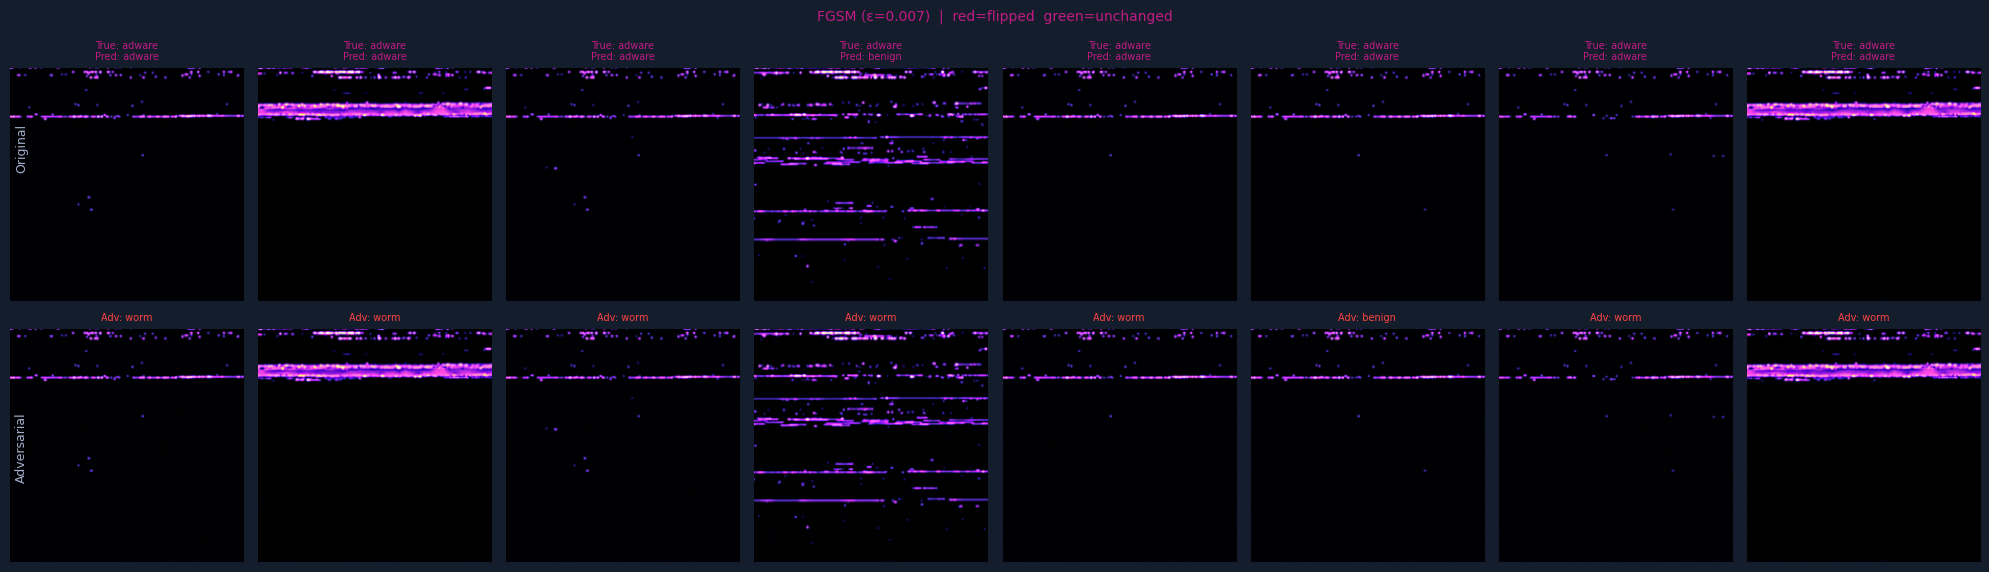

In [31]:
def show_fgsm_examples(images: Tensor, labels: Tensor, n: int = 8):
    import matplotlib.pyplot as plt

    mean = torch.tensor(NORM_MEAN, device=images.device).view(3, 1, 1)
    std  = torch.tensor(NORM_STD,  device=images.device).view(3, 1, 1)

    def to_img(t):
        return (t * std + mean).clamp(0, 1).permute(1, 2, 0).cpu().numpy()

    class_names = test_dataset.classes
    n = min(n, images.size(0))
    x_adv = fgsm_attack(images, labels)

    with torch.no_grad():
        clean_preds = model(images).argmax(dim=1)
        adv_preds   = model(x_adv).argmax(dim=1)

    fig, axes = plt.subplots(2, n, figsize=(n * 2.5, 6))
    fig.patch.set_facecolor("#141D2B")

    for i in range(n):
        true_lbl  = class_names[labels[i].item()]
        clean_lbl = class_names[clean_preds[i].item()]
        adv_lbl   = class_names[adv_preds[i].item()]
        flipped   = adv_preds[i] != labels[i]

        axes[0, i].imshow(to_img(images[i]))
        axes[0, i].set_title(f"True: {true_lbl}\nPred: {clean_lbl}", fontsize=7, color="#C11C84")
        axes[0, i].axis("off")

        axes[1, i].imshow(to_img(x_adv[i]))
        axes[1, i].set_title(f"Adv: {adv_lbl}", fontsize=7, color="#ff4444" if flipped else "#44ff44")
        axes[1, i].axis("off")

    fig.text(0.01, 0.75, "Original",    color="#A4B1CD", fontsize=9, va="center", rotation=90)
    fig.text(0.01, 0.25, "Adversarial", color="#A4B1CD", fontsize=9, va="center", rotation=90)
    fig.suptitle(f"FGSM (ε={EPSILON})  |  red=flipped  green=unchanged", color="#C11C84", fontsize=10)
    plt.tight_layout()
    plt.show()

# ── call it ──
sample_images, sample_labels = next(iter(test_loader))
sample_images, sample_labels = sample_images.to(device), sample_labels.to(device)
show_fgsm_examples(sample_images, sample_labels, n=8)

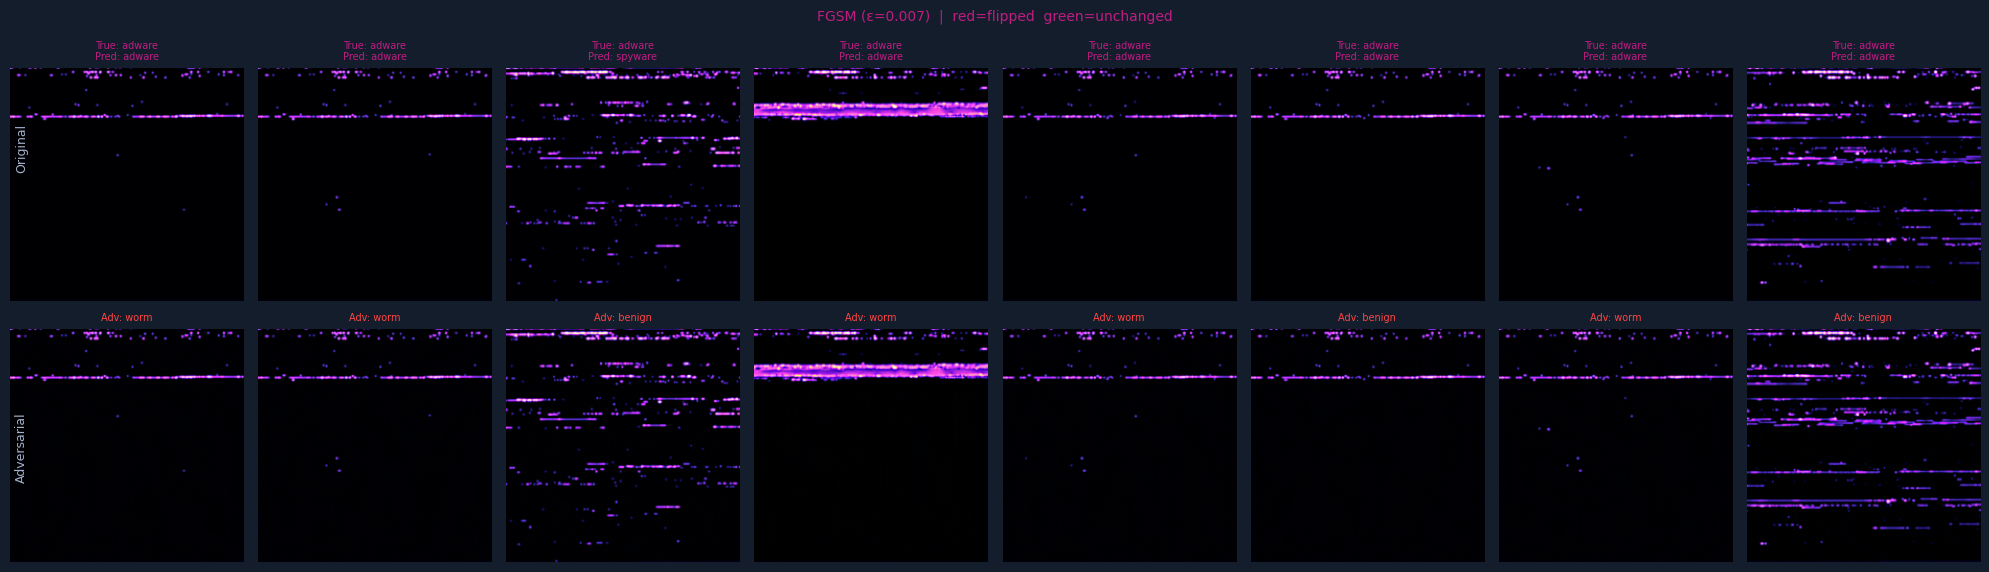

In [32]:
# change this number to see different samples (0 = first batch, 1 = second, etc.)
BATCH_INDEX = 2

for i, (imgs, lbls) in enumerate(test_loader):
    if i == BATCH_INDEX:
        sample_images, sample_labels = imgs.to(device), lbls.to(device)
        break

show_fgsm_examples(sample_images, sample_labels, n=8)

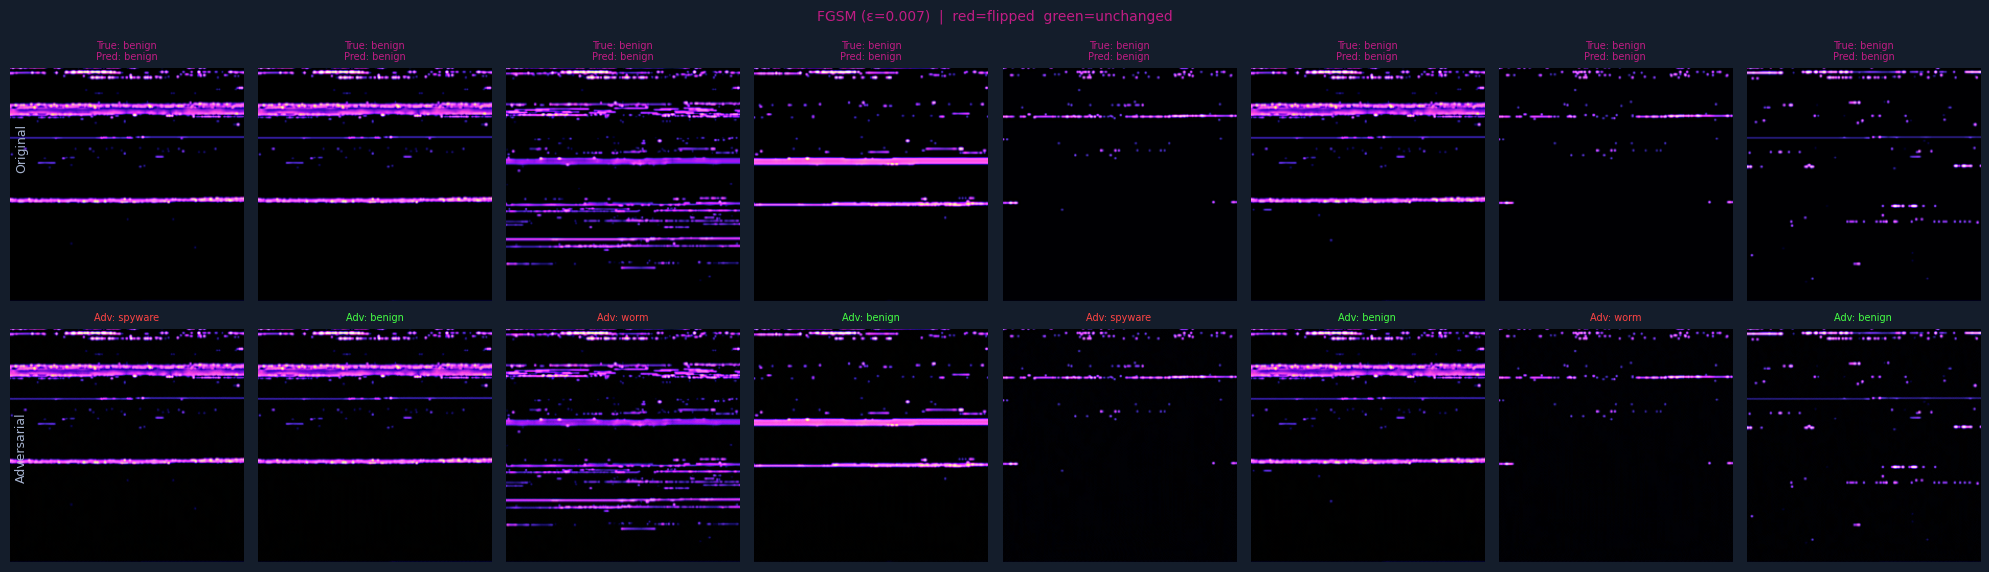

In [33]:
# change this number to see different samples (0 = first batch, 1 = second, etc.)
BATCH_INDEX = 16

for i, (imgs, lbls) in enumerate(test_loader):
    if i == BATCH_INDEX:
        sample_images, sample_labels = imgs.to(device), lbls.to(device)
        break

show_fgsm_examples(sample_images, sample_labels, n=8)